# Análise de Vendas - Loja

Este notebook organiza a análise de vendas por loja e por período.
Inclui limpeza de dados, agregações, visualizações e checagens de metas.

In [46]:
# Importações principais
import pandas as pd
import numpy as np
from datetime import datetime
from matplotlib import pyplot as plt

# Definir estilo de plot de forma segura (tenta estilos preferidos se disponíveis)
preferred_styles = ['seaborn-whitegrid', 'seaborn', 'ggplot']
for style_name in preferred_styles:
    if style_name in plt.style.available:
        plt.style.use(style_name)
        break

In [47]:
vendas_df = pd.read_csv('vendasTech.csv', sep=',', low_memory=False)
gerente_lojas_df = pd.read_excel('gerente_lojas.xlsx', decimal=',')

In [48]:

vendas_df['Loja'] = vendas_df['Loja'].fillna(vendas_df['Loja'].mode()[0])
vendas_df = vendas_df.drop(columns=['Data_Base'])

print(vendas_df)

        ID_Pedido        Data            Loja             Produto  \
0               1  2023-06-08       São Paulo         Mouse Gamer   
1               2  2023-03-01  Belo Horizonte           iPhone 14   
2               3  2023-02-25          Recife         Monitor 27"   
3               4  2024-11-19  RIO DE JANEIRO         Mouse Gamer   
4               5  2024-01-27  Rio de Janeiro  Smartphone Samsung   
...           ...         ...             ...                 ...   
100095      94091  2023-10-20    Porto Alegre           iPhone 14   
100096      52883  2024-03-17    Porto Alegre       Notebook Dell   
100097      65070  2023-06-19  Belo Horizonte  Smartphone Samsung   
100098      94031  2024-06-14        Salvador           iPhone 14   
100099      36755  2023-01-03      São Paulo          Notebook HP   

        Preco_Unitario  Qtd        Cliente  
0                120.0    1   Cliente_4095  
1               5500.0    1   Cliente_8750  
2               1200.0    1  Cliente

In [49]:
vendas_df['Loja'] = vendas_df['Loja'].str.lower()
display(vendas_df)


,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente
0,1,2023-06-08,são paulo,Mouse Gamer,120.0,1,Cliente_4095
1,2,2023-03-01,belo horizonte,iPhone 14,5500.0,1,Cliente_8750
2,3,2023-02-25,recife,"Monitor 27""",1200.0,1,Cliente_14859
3,4,2024-11-19,rio de janeiro,Mouse Gamer,120.0,2,Cliente_17343
4,5,2024-01-27,rio de janeiro,Smartphone Samsung,2200.0,1,Cliente_23377
...,...,...,...,...,...,...,...
100095,94091,2023-10-20,porto alegre,iPhone 14,5500.0,1,Cliente_11755
100096,52883,2024-03-17,porto alegre,Notebook Dell,3500.0,2,Cliente_12879
100097,65070,2023-06-19,belo horizonte,Smartphone Samsung,2200.0,2,Cliente_8160
100098,94031,2024-06-14,salvador,iPhone 14,5500.0,2,Cliente_28545


In [50]:
vendas_df['Data'] = pd.to_datetime(vendas_df['Data'], format='%Y-%m-%d')

In [51]:
vendas_df = vendas_df.drop_duplicates(subset=['ID_Pedido'])

In [52]:
vendas_df['Faturamento'] = vendas_df['Qtd'] * vendas_df['Preco_Unitario']
display(vendas_df)

,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Faturamento
0,1,2023-06-08,são paulo,Mouse Gamer,120.0,1,Cliente_4095,120.0
1,2,2023-03-01,belo horizonte,iPhone 14,5500.0,1,Cliente_8750,5500.0
2,3,2023-02-25,recife,"Monitor 27""",1200.0,1,Cliente_14859,1200.0
3,4,2024-11-19,rio de janeiro,Mouse Gamer,120.0,2,Cliente_17343,240.0
4,5,2024-01-27,rio de janeiro,Smartphone Samsung,2200.0,1,Cliente_23377,2200.0
...,...,...,...,...,...,...,...,...
99995,99996,2023-01-24,são paulo,Mouse Gamer,120.0,2,Cliente_13732,240.0
99996,99997,2024-08-28,rio de janeiro,Cabo HDMI,40.0,1,Cliente_25058,40.0
99997,99998,2024-03-18,curitiba,Smartphone Samsung,2200.0,2,Cliente_28864,4400.0
99998,99999,2023-11-04,porto alegre,iPhone 14,5500.0,1,Cliente_4205,5500.0


In [53]:
gerente_lojas_df['Loja'] = gerente_lojas_df['Loja'].str.lower()
display(gerente_lojas_df)

,Loja,Gerente,Meta_Mensal
0,são paulo,Carlos,50000
1,rio de janeiro,Fernanda,60000
2,curitiba,Roberto,45000
3,belo horizonte,Juliana,55000
4,recife,Marcos,48000
5,porto alegre,Pedro,42000
6,salvador,Ana,52000


In [54]:
vendas_df['Loja'] = vendas_df['Loja'].str.strip()


In [55]:
# Funções utilitárias úteis para a análise

def formatar(valor):
    """Formata um valor numérico em real (R$).
    Recebe float ou int; retorna string formatada.
    """
    try:
        return f'R${valor:,.2f}'
    except Exception:
        return valor

def definir_regioes(loja):
    """Mapeia o nome da loja para a região.
    Usa um dicionário interno e retorna 'desconhecido' se o nome não constar.
    """
    dic_regioes = {
        'são paulo': 'sudeste',
        'belo horizonte': 'sudeste',
        'recife': 'nordeste',
        'rio de janeiro': 'sudeste',
        'salvador': 'nordeste',
        'curitiba': 'sul',
        'porto alegre': 'sul'
    }
    if pd.isna(loja):
        return 'desconhecido'
    key = str(loja).strip().lower()
    return dic_regioes.get(key, 'desconhecido')

# Aplicar mapeamento de regiões de forma segura
vendas_df['Regiões'] = vendas_df['Loja'].apply(definir_regioes)

In [56]:
# pd.options.display.float_format = "R${:,.2f}".format
vendas_df = vendas_df.sort_values(by='Data')
display(vendas_df)

,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Faturamento,Regiões
34749,34750,2023-01-01,rio de janeiro,Notebook HP,3200.0,1,Cliente_9014,3200.0,sudeste
13698,13699,2023-01-01,rio de janeiro,Teclado Mecânico,250.0,1,Cliente_24330,250.0,sudeste
81393,81394,2023-01-01,porto alegre,Teclado Mecânico,250.0,1,Cliente_9758,250.0,sul
250,251,2023-01-01,são paulo,Teclado Mecânico,250.0,3,Cliente_22822,750.0,sudeste
77067,77068,2023-01-01,rio de janeiro,Notebook Dell,3500.0,1,Cliente_554,3500.0,sudeste
...,...,...,...,...,...,...,...,...,...
43206,43207,2024-12-30,belo horizonte,Notebook Dell,3500.0,2,Cliente_15893,7000.0,sudeste
3182,3183,2024-12-30,salvador,Mouse Gamer,120.0,1,Cliente_4075,120.0,nordeste
9460,9461,2024-12-30,porto alegre,Teclado Mecânico,250.0,1,Cliente_22763,250.0,sul
2792,2793,2024-12-30,salvador,Notebook Dell,3500.0,1,Cliente_24692,3500.0,nordeste


In [57]:
df_vendas_sp = vendas_df[vendas_df['Loja']== "são paulo"]
df_vendas_sp = df_vendas_sp[df_vendas_sp['Data'].dt.year == 2024]
display(df_vendas_sp)


,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Faturamento,Regiões
22734,22735,2024-01-01,são paulo,Cabo HDMI,40.0,1,Cliente_14772,40.0,sudeste
43285,43286,2024-01-01,são paulo,Notebook Dell,3500.0,10,Cliente_16453,35000.0,sudeste
83777,83778,2024-01-01,são paulo,iPhone 14,5500.0,1,Cliente_29052,5500.0,sudeste
16591,16592,2024-01-01,são paulo,Notebook HP,3200.0,1,Cliente_20650,3200.0,sudeste
19151,19152,2024-01-01,são paulo,Notebook HP,3200.0,5,Cliente_25346,16000.0,sudeste
...,...,...,...,...,...,...,...,...,...
80510,80511,2024-12-30,são paulo,Notebook Dell,3500.0,1,Cliente_487,3500.0,sudeste
79130,79131,2024-12-30,são paulo,Notebook Dell,3500.0,1,Cliente_2298,3500.0,sudeste
93753,93754,2024-12-30,são paulo,Notebook Dell,3500.0,1,Cliente_9966,3500.0,sudeste
28532,28533,2024-12-30,são paulo,Smartphone Samsung,2200.0,2,Cliente_5400,4400.0,sudeste


In [58]:
faturamento_sp_2024 = df_vendas_sp['Faturamento'].sum()
print(f"faturamento do ano de 2024 na cidade de São Paulo : R${faturamento_sp_2024:,.2f}")

faturamento do ano de 2024 na cidade de São Paulo : R$21,320,340.00


In [59]:
vendas_rj_2024 = vendas_df[vendas_df['Loja'] == 'rio de janeiro']
vendas_rj_2024 = vendas_rj_2024[vendas_rj_2024['Data'].dt.year == 2024]

faturamento_rj_2024 = vendas_rj_2024['Faturamento'].sum()
display(vendas_rj_2024)
print(f"faturamento do ano de 2024 na cidade do Rio de Janeiro foi de : R${faturamento_rj_2024:,.2f}")

,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Faturamento,Regiões
58388,58389,2024-01-01,rio de janeiro,iPhone 14,5500.0,1,Cliente_15437,5500.0,sudeste
72739,72740,2024-01-01,rio de janeiro,Notebook Dell,3500.0,1,Cliente_25865,3500.0,sudeste
64502,64503,2024-01-01,rio de janeiro,Mouse Gamer,120.0,1,Cliente_462,120.0,sudeste
96783,96784,2024-01-01,rio de janeiro,Notebook HP,3200.0,1,Cliente_14331,3200.0,sudeste
1336,1337,2024-01-01,rio de janeiro,Smartphone Samsung,2200.0,3,Cliente_18484,6600.0,sudeste
...,...,...,...,...,...,...,...,...,...
89339,89340,2024-12-30,rio de janeiro,Notebook HP,3200.0,1,Cliente_9927,3200.0,sudeste
93316,93317,2024-12-30,rio de janeiro,Cabo HDMI,40.0,1,Cliente_27808,40.0,sudeste
83946,83947,2024-12-30,rio de janeiro,Notebook HP,3200.0,1,Cliente_18486,3200.0,sudeste
1136,1137,2024-12-30,rio de janeiro,Mouse Gamer,120.0,1,Cliente_16524,120.0,sudeste


faturamento do ano de 2024 na cidade do Rio de Janeiro foi de : R$21,233,410.00


faturamento_rj_2024 = vendas_df[(vendas_df['Loja'] == 'rio de janeiro') & (vendas_df['Data'].dt.year == 2024)
]

In [60]:
display(vendas_df.head())

,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Faturamento,Regiões
34749,34750,2023-01-01,rio de janeiro,Notebook HP,3200.0,1,Cliente_9014,3200.0,sudeste
13698,13699,2023-01-01,rio de janeiro,Teclado Mecânico,250.0,1,Cliente_24330,250.0,sudeste
81393,81394,2023-01-01,porto alegre,Teclado Mecânico,250.0,1,Cliente_9758,250.0,sul
250,251,2023-01-01,são paulo,Teclado Mecânico,250.0,3,Cliente_22822,750.0,sudeste
77067,77068,2023-01-01,rio de janeiro,Notebook Dell,3500.0,1,Cliente_554,3500.0,sudeste


In [61]:
def formatar(valor):
  valor_formatado = f'R${valor:,.2f}'
  return valor_formatado


vendas_por_loja = vendas_df[['Loja', 'Faturamento']].groupby('Loja').sum()
vendas_por_loja = vendas_por_loja.sort_values(by='Faturamento', ascending=False)
vendas_por_loja = vendas_por_loja.reset_index()
vendas_por_loja['Faturamento'] = vendas_por_loja['Faturamento'].apply(formatar)
display(vendas_por_loja)


,Loja,Faturamento
0,recife,"R$48,271,240.00"
1,salvador,"R$42,300,610.00"
2,rio de janeiro,"R$42,294,720.00"
3,são paulo,"R$42,090,690.00"
4,belo horizonte,"R$41,714,890.00"
5,porto alegre,"R$41,678,460.00"
6,curitiba,"R$41,121,720.00"


In [62]:
from matplotlib import pyplot as plt

produtos_mais_vendeu_sp = df_vendas_sp[['Produto', 'Qtd']].groupby('Produto').sum()
produtos_mais_vendeu_sp.rename(columns={'Qtd': 'Quantidade'}, inplace=True)
produtos_mais_vendeu_sp = produtos_mais_vendeu_sp.sort_values(by='Quantidade', ascending=False)
produtos_mais_vendeu_sp = produtos_mais_vendeu_sp.reset_index()
display(produtos_mais_vendeu_sp)

,Produto,Quantidade
0,iPhone 14,1415
1,"Monitor 27""",1392
2,Cabo HDMI,1323
3,Mouse Gamer,1321
4,Notebook HP,1310
5,Notebook Dell,1278
6,Smartphone Samsung,1225
7,Teclado Mecânico,1184


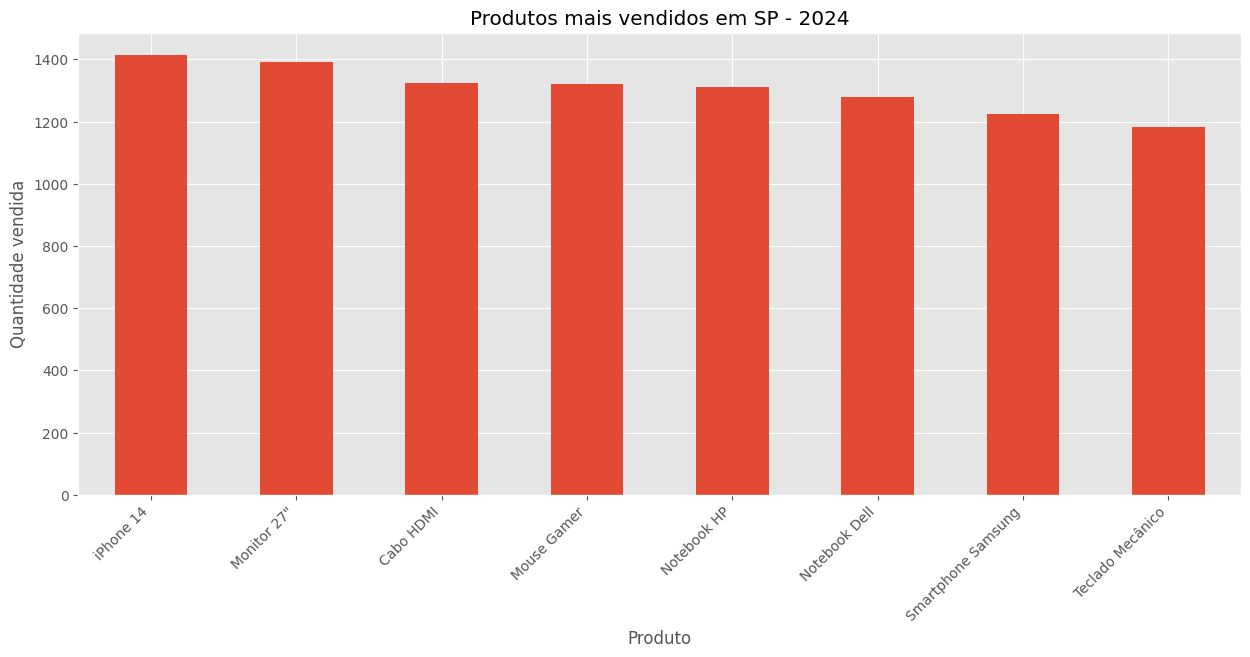

In [63]:
produtos_mais_vendeu_sp.plot(
    kind='bar',
    x='Produto',  
    y='Quantidade',    
    figsize=(15,6),
    legend=False       
)

plt.title("Produtos mais vendidos em SP - 2024")
plt.ylabel("Quantidade vendida")
plt.xticks(rotation=45, ha='right')  # gira os nomes para não ficarem sobrepostos
plt.show()


In [64]:
produto_por_loja = vendas_df[['Produto', 'Loja', 'Qtd']].groupby(['Loja', 'Produto']).sum()
display(produto_por_loja)

Qtd
Loja           Produto                 
belo horizonte Cabo HDMI           2636
               Monitor 27"         2625
               Mouse Gamer         2465
               Notebook Dell       2654
               Notebook HP         2775
               Smartphone Samsung  2597
               Teclado Mecânico    2609
               iPhone 14           2478
curitiba       Cabo HDMI           2698
               Monitor 27"         2626
               Mouse Gamer         2600
               Notebook Dell       2517
               Notebook HP         2529
               Smartphone Samsung  2444
               Teclado Mecânico    2742
               iPhone 14           2652
porto alegre   Cabo HDMI           2571
               Monitor 27"         2655
               Mouse Gamer         2611
               Notebook Dell       2770
               Notebook HP         2511
               Smartphone Samsung  2603
               Teclado Mecânico    2598
               iPhone 14           2540
recife         Cabo HDMI           2937
               Monitor 27"         2979
               Mouse Gamer         3018
               Notebook Dell       2935
               Notebook HP         3093
               Smartphone Samsung  2971
               Teclado Mecânico    3118
               iPhone 14           3042
rio de janeiro Cabo HDMI           2747
               Monitor 27"         2798
               Mouse Gamer         2652
               Notebook Dell       2534
               Notebook HP         2614
               Smartphone Samsung  2626
               Teclado Mecânico    2548
               iPhone 14           2702
salvador       Cabo HDMI           2566
               Monitor 27"         2545
               Mouse Gamer         2711
               Notebook Dell       2512
               Notebook HP         2785
               Smartphone Samsung  2627
               Teclado Mecânico    2579
               iPhone 14           2671
são paulo      Cabo HDMI           2649
               Monitor 27"         2796
               Mouse Gamer         2714
               Notebook Dell       2535
               Notebook HP         2592
               Smartphone Samsung  2476
               Teclado Mecânico    2589
               iPhone 14           2735

In [65]:
df_meta = vendas_df[(vendas_df['Data'].dt.year == 2023 )& (vendas_df['Data'].dt.month == 1)]
df_meta = df_meta[['Loja', 'Faturamento']].groupby('Loja').sum()
df_meta = df_meta.reset_index()

In [66]:
meta_gerente = df_meta.merge(gerente_lojas_df[['Loja', 'Gerente', 'Meta_Mensal']], on='Loja')
display(meta_gerente)

,Loja,Faturamento,Gerente,Meta_Mensal
0,belo horizonte,1779100.0,Juliana,55000
1,curitiba,1986920.0,Roberto,45000
2,porto alegre,1726640.0,Pedro,42000
3,recife,2183590.0,Marcos,48000
4,rio de janeiro,1736830.0,Fernanda,60000
5,salvador,1686070.0,Ana,52000
6,são paulo,1831140.0,Carlos,50000


In [67]:
meta_gerente['Loja'] = meta_gerente['Loja'].str.capitalize()

In [68]:
meta_gerente['Bateu a meta'] = np.where(meta_gerente['Faturamento'] >= meta_gerente['Meta_Mensal'], 'Sim', 'Não')
display(meta_gerente)

,Loja,Faturamento,Gerente,Meta_Mensal,Bateu a meta
0,Belo horizonte,1779100.0,Juliana,55000,Sim
1,Curitiba,1986920.0,Roberto,45000,Sim
2,Porto alegre,1726640.0,Pedro,42000,Sim
3,Recife,2183590.0,Marcos,48000,Sim
4,Rio de janeiro,1736830.0,Fernanda,60000,Sim
5,Salvador,1686070.0,Ana,52000,Sim
6,São paulo,1831140.0,Carlos,50000,Sim


In [69]:
vendas_df['Mes-Ano'] = vendas_df['Data'].dt.to_period("M")

vendas_df_mes = vendas_df[['Mes-Ano', 'Faturamento']].groupby('Mes-Ano').sum()
vendas_df_mes = vendas_df_mes.sort_values('Faturamento')
# vendas_df_mes = vendas_df_mes['Faturamento'].apply(formatar)
display(vendas_df_mes)

,Faturamento
Mes-Ano,
2023-02,11515150.0
2024-02,11666800.0
2023-11,11883670.0
2024-11,11924910.0
2024-09,12001410.0
2023-09,12118180.0
2024-06,12356650.0
2023-06,12455820.0
2024-04,12461860.0


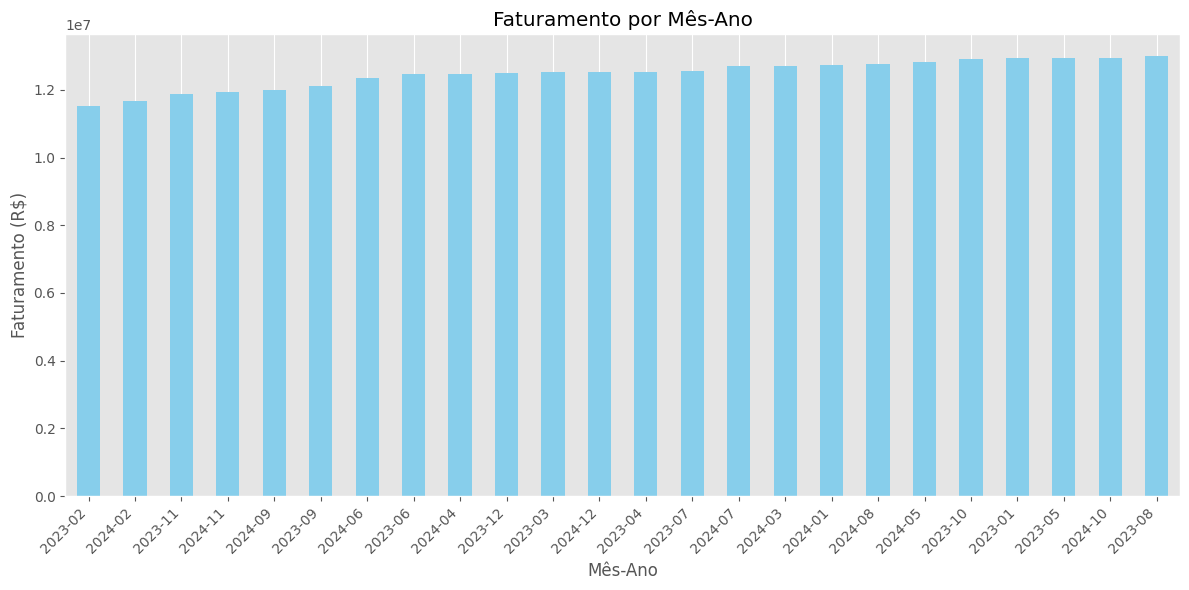

In [70]:
# Visualização do faturamento por mês-ano
plt.figure(figsize=(12,6))
# Convertendo o período para string para exibição mais legível
vendas_df_mes_plot = vendas_df_mes.copy()
if isinstance(vendas_df_mes_plot.index, pd.PeriodIndex):
    vendas_df_mes_plot.index = vendas_df_mes_plot.index.astype(str)
vendas_df_mes_plot['Faturamento'].plot(kind='bar', color='skyblue')

plt.title("Faturamento por Mês-Ano")
plt.xlabel("Mês-Ano")
plt.ylabel("Faturamento (R$)")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()